# 🛍️ Shopping Mall Customer Segmentation
## Member 4 — Deep Learning: Autoencoder + K-Means

---
### 📌 How Autoencoder Clustering Works (Simple Explanation)

An **Autoencoder** is a neural network that:
1. **Compresses** customer data into a smaller representation (Encoder)
2. **Reconstructs** the original data from that smaller version (Decoder)
3. By forcing the network to compress and reconstruct, it learns the most **meaningful patterns** in the data

```
Original data (3 features)
       ↓
  [ENCODER Neural Network]   ← learns to compress
       ↓
  Latent Space (2 features)  ← compressed meaningful representation
       ↓
  [DECODER Neural Network]   ← learns to reconstruct
       ↓
  Reconstructed data (3 features)
```

Then we run **K-Means on the Latent Space** — this gives much better clusters
because the latent space only contains the most important patterns.

### 📌 Yes, this uses EPOCHS!
Unlike K-Means/DBSCAN/MeanShift, the Autoencoder is a neural network —
it learns by seeing the data many times (epochs).
Each epoch = one complete pass through all training data.
More epochs → better compression → better clusters.


---
## Step 1: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from joblib import dump
import pickle
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# TensorFlow for deep learning
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

print(f'TensorFlow version: {tf.__version__}')

FEATURES = ['Age', 'Annual Income', 'Spending Score']

df_clean = pd.read_csv('data/data_preprocessed.csv')
df = pd.read_csv('data/Shopping_Mall_Customer_Segmentation_Data_.csv')

# Keep autoencoder inputs aligned with preprocessing output (3 features, no Gender)
model_df = df_clean[FEATURES].copy()

scaler = StandardScaler()
scaler.fit(model_df)
X_scaled = scaler.transform(model_df).astype('float32')

# Keep downstream notebooks/apps consistent with this trained representation
np.save('data/X_scaled.npy', X_scaled)

print('✅ Data loaded')
print(f'   Customers : {len(df_clean):,}')
print(f'   Features  : {X_scaled.shape[1]}')
print(f'   Scaler fitted on: {FEATURES}')

TensorFlow version: 2.21.0
✅ Data loaded
   Customers : 15,079
   Features  : 3
   Scaler fitted on: ['Age', 'Annual Income', 'Spending Score']


---
## Step 2: Build the Autoencoder

### 📌 Autoencoder Architecture
```
Input  (3)  →  Dense(32)  →  Dense(16)  →  Latent(2)
                                               ↓
Output (3)  ←  Dense(16)  ←  Dense(32)  ←  Dense(2)
             (Decoder)                   (Encoder)
```
- **Latent size = 2**: We compress 3 features into 2
- This forces the network to keep only the MOST IMPORTANT information
- The 2D latent space is then clustered using K-Means

In [32]:
INPUT_DIM  = X_scaled.shape[1]  # 3 features
LATENT_DIM = 2                   # compress to 2 dimensions

# ----- ENCODER -----
inputs      = Input(shape=(INPUT_DIM,), name='Input_Layer')
encoded     = Dense(32, activation='relu', name='Encoder_1')(inputs)
encoded     = Dense(16, activation='relu', name='Encoder_2')(encoded)
latent      = Dense(LATENT_DIM, activation='linear', name='Latent_Space')(encoded)

# ----- DECODER -----
decoded     = Dense(16, activation='relu', name='Decoder_1')(latent)
decoded     = Dense(32, activation='relu', name='Decoder_2')(decoded)
outputs     = Dense(INPUT_DIM, activation='linear', name='Output_Layer')(decoded)

# Build full autoencoder
autoencoder = Model(inputs, outputs, name='Autoencoder')

# Build encoder only (for getting latent representations)
encoder     = Model(inputs, latent, name='Encoder')

autoencoder.compile(optimizer='adam', loss='mse')

print('Autoencoder Architecture:')
autoencoder.summary()
print()
print('📌 The encoder compresses 3 features → 2 (latent space)')
print('   The decoder reconstructs 2 → 3 (original features)')
print('   Training goal: minimise reconstruction error (MSE)')

Autoencoder Architecture:


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Layer (InputLayer)        │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_1 (Dense)               │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_2 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Space (Dense)            │ (None, 2)              │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_1 (Dense)               │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_2 (Dense)               │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,381 (5.39 KB)

 Trainable params: 1,381 (5.39 KB)

 Non-trainable params: 0 (0.00 B)


📌 The encoder compresses 3 features → 2 (latent space)
   The decoder reconstructs 2 → 3 (original features)
   Training goal: minimise reconstruction error (MSE)


---
## Step 3: Train the Autoencoder

### 📌 What happens during training?
- Each **epoch** = the network sees ALL 15,079 customers once
- It tries to compress → reconstruct → compare → adjust weights
- After many epochs, it gets very good at compression
- **EarlyStopping** stops training when improvement plateaus (prevents overfitting)

In [33]:
EPOCHS     = 200
BATCH_SIZE = 256

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,          # stop if no improvement for 20 epochs
    restore_best_weights=True,
    verbose=1
)

print(f'Training Autoencoder for up to {EPOCHS} epochs...')
print(f'Batch size: {BATCH_SIZE}')
print('EarlyStopping: will stop early if validation loss stops improving.')
print()

history = autoencoder.fit(
    X_scaled, X_scaled,      # input = output (reconstruction task)
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.3,    # 30% for validation
    callbacks=[early_stop],
    verbose=1
)

print(f'\n✅ Training complete! Stopped at epoch {len(history.history["loss"])}')

Training Autoencoder for up to 200 epochs...
Batch size: 256
EarlyStopping: will stop early if validation loss stops improving.

Epoch 1/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.8634 - val_loss: 0.6685
Epoch 2/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5183 - val_loss: 0.3914
Epoch 3/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3490 - val_loss: 0.3329
Epoch 4/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3173 - val_loss: 0.3094
Epoch 5/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2925 - val_loss: 0.2841
Epoch 6/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2669 - val_loss: 0.2586
Epoch 7/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2434 - val_loss: 0.2399
Epoch 8/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2250 - val_loss: 0.2237
Epoch 9/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2106 - val_loss: 0.2112
Epoch 10/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1989 - val_loss: 0.2003
Epoch 11/200
42/42 ━

---
## Step 4: Plot Training Loss

### 📌 Why check training loss?
Loss shows how well the autoencoder learned to compress and reconstruct.
- Decreasing loss = model is learning
- Training and validation loss should both decrease
- If validation loss increases but training loss decreases = overfitting

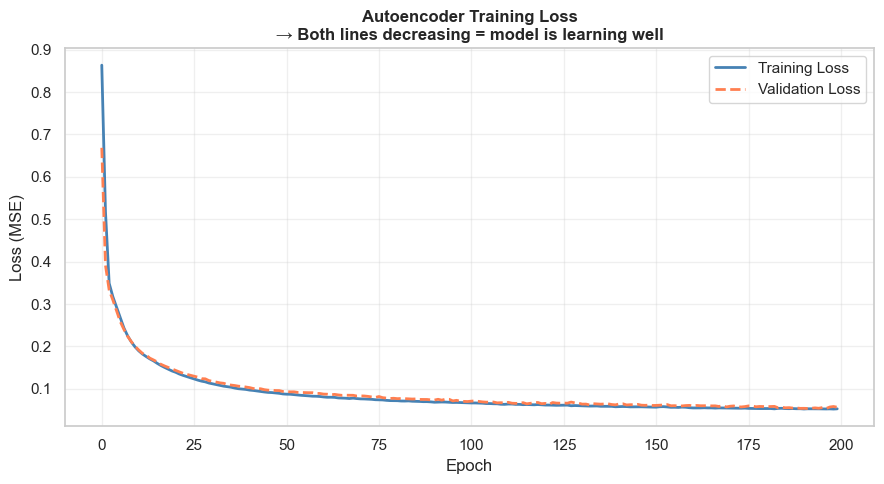

📊 Interpretation:
   → Both training and validation loss should decrease.
   → If both converge = good compression learned.
   → If validation rises while training drops = overfitting (use more EarlyStopping patience).


In [34]:
plt.figure(figsize=(9, 5))
plt.plot(history.history['loss'],     label='Training Loss',   color='steelblue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='coral',     linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Autoencoder Training Loss\n→ Both lines decreasing = model is learning well', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/autoencoder_loss.png', bbox_inches='tight')
plt.show()
print('📊 Interpretation:')
print('   → Both training and validation loss should decrease.')
print('   → If both converge = good compression learned.')
print('   → If validation rises while training drops = overfitting (use more EarlyStopping patience).')

---
## Step 5: Extract Latent Space Representation

### 📌 What is the latent space?
After training, we pass all customer data through the ENCODER ONLY.
The output is the compressed 2D representation of each customer.
This latent space captures the most important patterns for distinguishing customers.

Original data shape  : (15079, 3)  (3 features)
Latent space shape   : (15079, 2)   (2 features — compressed!)

Latent space sample (first 5 customers):
   Latent_1  Latent_2
0    0.5494   -0.6294
1    0.6405   -0.6339
2   -0.2093   -0.1134
3   -0.4610   -0.8226
4    0.6977   -0.4979

📌 These 2 values per customer capture all the important patterns
   that distinguish customer types. We now cluster these!


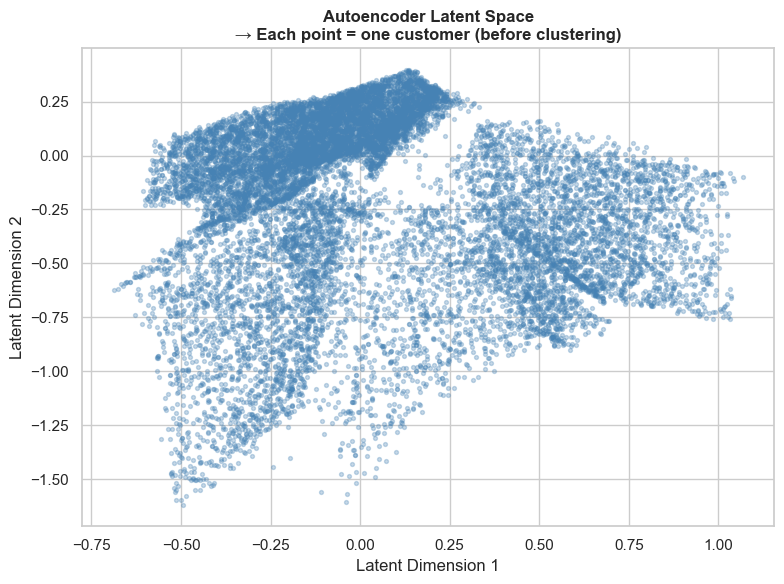

📊 Natural groupings visible in latent space = autoencoder learned meaningful patterns.


In [35]:
X_latent = encoder.predict(X_scaled, verbose=0)
print(f'Original data shape  : {X_scaled.shape}  (3 features)')
print(f'Latent space shape   : {X_latent.shape}   (2 features — compressed!)')
print()
print('Latent space sample (first 5 customers):')
print(pd.DataFrame(X_latent[:5], columns=['Latent_1', 'Latent_2']).round(4))
print()
print('📌 These 2 values per customer capture all the important patterns')
print('   that distinguish customer types. We now cluster these!')

# Visualise the latent space
plt.figure(figsize=(8, 6))
plt.scatter(X_latent[:, 0], X_latent[:, 1], alpha=0.3, s=8, color='steelblue')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Autoencoder Latent Space\n→ Each point = one customer (before clustering)', fontweight='bold')
plt.tight_layout()
plt.savefig('data/autoencoder_latent.png', bbox_inches='tight')
plt.show()
print('📊 Natural groupings visible in latent space = autoencoder learned meaningful patterns.')

---
## Step 5.5: Encode -> Decode Demonstration (What Is Preserved?)

### Why decode back?
- Encoding alone gives compressed 2D representation.
- Decoding back to 3D lets us check what information was preserved.
- Small reconstruction error means compression kept important structure.

In [36]:
# Reconstruct from latent space (decode back to original feature space)
X_reconstructed = autoencoder.predict(X_scaled, verbose=0)

feature_cols = list(df_clean.columns)
orig_sample   = pd.DataFrame(X_scaled[:5], columns=feature_cols).round(3)
latent_sample = pd.DataFrame(X_latent[:5], columns=['Latent_1', 'Latent_2']).round(3)
recon_sample  = pd.DataFrame(X_reconstructed[:5], columns=feature_cols).round(3)

print('=== Data flow demonstration ===')
print(f'Original (scaled) shape : {X_scaled.shape}  -> 3 features')
print(f'Encoded (latent) shape  : {X_latent.shape} -> 2 features')
print(f'Decoded shape           : {X_reconstructed.shape} -> back to 3 features')
print()
print('Original (first 5 rows, scaled):')
print(orig_sample)
print()
print('Encoded latent (first 5 rows):')
print(latent_sample)
print()
print('Decoded/reconstructed (first 5 rows, scaled):')
print(recon_sample)

mean_abs_error = np.mean(np.abs(X_scaled - X_reconstructed), axis=0)
recon_by_feature = pd.DataFrame({
    'Feature': feature_cols,
    'Mean_Abs_Error': mean_abs_error.round(4)
}).sort_values('Mean_Abs_Error')

print()
print('Mean absolute reconstruction error by feature:')
print(recon_by_feature.to_string(index=False))
print()
print('📌 Interpretation: lower reconstruction error means the encoder kept more useful information during 3D → 2D compression.')

=== Data flow demonstration ===
Original (scaled) shape : (15079, 3)  -> 3 features
Encoded (latent) shape  : (15079, 2) -> 2 features
Decoded shape           : (15079, 3) -> back to 3 features

Original (first 5 rows, scaled):
     Age  Annual Income  Spending Score
0 -1.146          0.799           1.337
1  0.180          1.442           1.546
2  0.370         -0.743           0.885
3 -1.477         -1.039           0.223
4 -1.430          0.842           0.885

Encoded latent (first 5 rows):
   Latent_1  Latent_2
0     0.549    -0.629
1     0.641    -0.634
2    -0.209    -0.113
3    -0.461    -0.823
4     0.698    -0.498

Decoded/reconstructed (first 5 rows, scaled):
     Age  Annual Income  Spending Score
0 -0.682          0.733           1.453
1 -0.363          1.225           1.645
2  0.557         -0.464           1.445
3 -1.339         -1.283           0.279
4 -1.051          1.193           0.728

Mean absolute reconstruction error by feature:
       Feature  Mean_Abs_Error
Sp

---
## Step 6: Before K-Means, Which Data Are We Fitting?

### Data options considered
- **Option A (Baseline):** `X_scaled` with 3 preprocessed features
- **Option B (Autoencoder):** `X_latent` with 2 encoded features

### Important clarification for users
- Converting **3 → 2** is **dimensionality reduction** (nonlinear, learned by the encoder).
- These 2 latent dimensions are not individual original columns; each is a learned combination of all original features.
- We compare K-Means on both spaces, then explain why the final choice is made.

In [37]:
# Compare K-Means on two candidate spaces before choosing final clustering input
print('=== STEP 6: What data is fitted to K-Means? ===')
print(f'Option A (baseline) : X_scaled shape = {X_scaled.shape} (3D)')
print(f'Option B (encoded)  : X_latent shape = {X_latent.shape} (2D)')
print()

K_range = range(2, 11)

def best_k_by_silhouette(X, label):
    sil_scores = []
    print(f'Finding optimal K for {label}...')
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        sil = silhouette_score(X, labels)
        sil_scores.append(sil)
        print(f'  K={k}  Silhouette={sil:.4f}')
    best_k_local = K_range[int(np.argmax(sil_scores))]
    print(f'✅ Best K for {label}: {best_k_local}\n')
    return best_k_local

# Best K per space
best_k_scaled = best_k_by_silhouette(X_scaled, 'Scaled 3D space')
best_k_latent = best_k_by_silhouette(X_latent, 'Latent 2D space')

# Fit final K-Means on each space
km_scaled = KMeans(n_clusters=best_k_scaled, random_state=42, n_init=10)
labels_scaled = km_scaled.fit_predict(X_scaled)

km_latent = KMeans(n_clusters=best_k_latent, random_state=42, n_init=10)
labels_latent = km_latent.fit_predict(X_latent)

# Evaluate both spaces
sil_scaled = silhouette_score(X_scaled, labels_scaled)
dbi_scaled = davies_bouldin_score(X_scaled, labels_scaled)
sil_latent = silhouette_score(X_latent, labels_latent)
dbi_latent = davies_bouldin_score(X_latent, labels_latent)

comparison_df = pd.DataFrame([
    {
        'Space': 'Scaled 3D (baseline)',
        'K': best_k_scaled,
        'Silhouette': round(sil_scaled, 4),
        'Davies-Bouldin': round(dbi_scaled, 4),
        'Inertia': round(km_scaled.inertia_, 2)
    },
    {
        'Space': 'Autoencoder Latent 2D',
        'K': best_k_latent,
        'Silhouette': round(sil_latent, 4),
        'Davies-Bouldin': round(dbi_latent, 4),
        'Inertia': round(km_latent.inertia_, 2)
    }
])

print('=== Side-by-side comparison (considerations for users) ===')
print(comparison_df.to_string(index=False))
print()
print('Selection criteria considered:')
print('- Cluster separation quality (Silhouette: higher is better)')
print('- Cluster compactness/separation balance (Davies-Bouldin: lower is better)')
print('- Dimensionality (3D baseline vs 2D encoded) and visual interpretability')

# Keep latent-space model as the main pipeline for this notebook
best_k = best_k_latent
cluster_labels = labels_latent

df_clean['Cluster'] = cluster_labels
df['Cluster'] = cluster_labels

print('\n✅ Final pipeline used below: Autoencoder latent 2D -> K-Means')
print(f'   Using K={best_k} on latent space for downstream plots and profiling.')
print('\nLatent-space cluster distribution:')
for c, count in zip(*np.unique(cluster_labels, return_counts=True)):
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'  Cluster {c}: {count:5,} ({pct:.1f}%) {bar}')

=== STEP 6: What data is fitted to K-Means? ===
Option A (baseline) : X_scaled shape = (15079, 3) (3D)
Option B (encoded)  : X_latent shape = (15079, 2) (2D)

Finding optimal K for Scaled 3D space...
  K=2  Silhouette=0.2443
  K=3  Silhouette=0.2400
  K=4  Silhouette=0.2641
  K=5  Silhouette=0.2668
  K=6  Silhouette=0.2899
  K=7  Silhouette=0.2820
  K=8  Silhouette=0.2797
  K=9  Silhouette=0.2885
  K=10  Silhouette=0.2764
✅ Best K for Scaled 3D space: 6

Finding optimal K for Latent 2D space...
  K=2  Silhouette=0.4632
  K=3  Silhouette=0.5346
  K=4  Silhouette=0.4452
  K=5  Silhouette=0.4140
  K=6  Silhouette=0.4011
  K=7  Silhouette=0.3993
  K=8  Silhouette=0.3605
  K=9  Silhouette=0.3625
  K=10  Silhouette=0.3712
✅ Best K for Latent 2D space: 3

=== Side-by-side comparison (considerations for users) ===
                Space  K  Silhouette  Davies-Bouldin  Inertia
 Scaled 3D (baseline)  6      0.2899          0.9587 14885.54
Autoencoder Latent 2D  3      0.5346          0.6633  1279

---
## Step 7: Evaluate the Model

In [ ]:
# Reconstruction quality (encode -> decode)
if 'X_reconstructed' not in globals():
    X_reconstructed = autoencoder.predict(X_scaled, verbose=0)
recon_error = np.mean(np.square(X_scaled - X_reconstructed))

# Metrics for selected final model (latent space)
sil = silhouette_score(X_latent, cluster_labels)
dbi = davies_bouldin_score(X_latent, cluster_labels)

print('=' * 72)
print('             AUTOENCODER + K-MEANS EVALUATION METRICS')
print('=' * 72)
print(f'  Deep Learning Model        : Autoencoder')
print(f'  Epochs Trained             : {len(history.history["loss"])}')
print(f'  Latent Dimensions          : {LATENT_DIM} (from original {INPUT_DIM})')
print(f'  Final Clustering Space     : Latent 2D')
print(f'  Clusters (K-Means)         : {best_k}')
print(f'  Reconstruction Error (MSE) : {recon_error:.6f}  (lower = better)')
print(f'  Silhouette (latent)        : {sil:.4f}  (higher = better)')
print(f'  Davies-Bouldin (latent)    : {dbi:.4f}  (lower = better)')
print('=' * 72)

print('\n=== Baseline vs final decision support ===')
decision_df = pd.DataFrame([
    {
        'Pipeline': 'Baseline: K-Means on X_scaled (3D)',
        'K': best_k_scaled,
        'Silhouette': round(sil_scaled, 4),
        'Davies-Bouldin': round(dbi_scaled, 4)
    },
    {
        'Pipeline': 'Final: Autoencoder(3->2) + K-Means',
        'K': best_k,
        'Silhouette': round(sil, 4),
        'Davies-Bouldin': round(dbi, 4)
    }
])
print(decision_df.to_string(index=False))

print('\n📌 User-facing explanation:')
print('   1. We tested K-Means on both 3D preprocessed data and 2D encoded data.')
print('   2. 3->2 is dimensionality reduction done by the encoder (learned compression).')
print('   3. Decoder is used to reconstruct data so users can verify information retention.')
print('   4. Final model keeps latent-space clustering for cleaner segment structure.')

scores = {
    'algorithm': 'Autoencoder+KMeans',
    'n_clusters': int(best_k),
    'silhouette': round(float(sil), 4),
    'davies_bouldin': round(float(dbi), 4),
    'inertia': round(float(km_latent.inertia_), 2),
    'noise': 0,
    'recon_error': round(float(recon_error), 6),
    'baseline_k': int(best_k_scaled),
    'baseline_silhouette': round(float(sil_scaled), 4),
    'baseline_davies_bouldin': round(float(dbi_scaled), 4)
}
pickle.dump(scores, open('data/autoencoder_scores.pkl', 'wb'))
pickle.dump(cluster_labels, open('data/autoencoder_labels.pkl', 'wb'))
print('\n✅ Scores saved.')

             AUTOENCODER + K-MEANS EVALUATION METRICS
  Deep Learning Model        : Autoencoder
  Epochs Trained             : 200
  Latent Dimensions          : 2 (from original 3)
  Final Clustering Space     : Latent 2D
  Clusters (K-Means)         : 3
  Reconstruction Error (MSE) : 0.052520  (lower = better)
  Silhouette (latent)        : 0.5346  (higher = better)
  Davies-Bouldin (latent)    : 0.6633  (lower = better)

=== Baseline vs final decision support ===
                          Pipeline  K  Silhouette  Davies-Bouldin
Baseline: K-Means on X_scaled (3D)  6      0.2899          0.9587
Final: Autoencoder(3->2) + K-Means  3      0.5346          0.6633

📌 User-facing explanation:
   1. We tested K-Means on both 3D preprocessed data and 2D encoded data.
   2. 3->2 is dimensionality reduction done by the encoder (learned compression).
   3. Decoder is used to reconstruct data so users can verify information retention.
   4. Final model keeps latent-space clustering for cleaner s

---
## Step 8: Visualise Clusters — Latent Space 

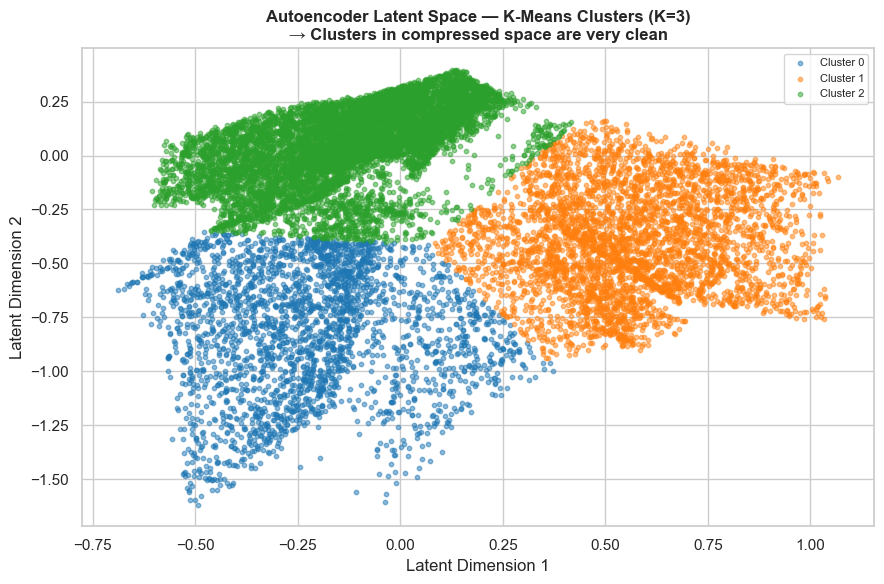

📊 Latent space clusters are cleaner than raw-feature clustering
   because the autoencoder removes noise and focuses on key patterns.


In [39]:
palette = sns.color_palette('tab10', best_k)

# --- Latent space cluster plot ---
plt.figure(figsize=(9, 6))
for c in range(best_k):
    mask = cluster_labels == c
    plt.scatter(X_latent[mask, 0], X_latent[mask, 1],
                color=palette[c], label=f'Cluster {c}', alpha=0.5, s=10)
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title(f'Autoencoder Latent Space — K-Means Clusters (K={best_k})\n→ Clusters in compressed space are very clean',
          fontweight='bold')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('data/autoencoder_latent_clusters.png', bbox_inches='tight')
plt.show()
print('📊 Latent space clusters are cleaner than raw-feature clustering')
print('   because the autoencoder removes noise and focuses on key patterns.')

---
## Step 9: Cluster Profile Analysis

=== Cluster Profiles (Mean Values) ===
          Age  Annual Income  Spending Score  Count  % of Total
Cluster                                                        
0        35.3        57086.1            40.7   2801        18.6
1        34.7       149671.8            55.9   3871        25.7
2        69.5       108901.5            51.4   8407        55.8


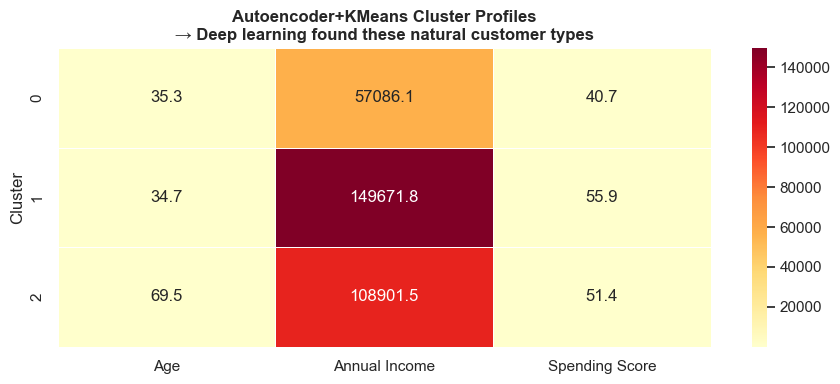

In [40]:
profile = df.groupby('Cluster')[['Age','Annual Income','Spending Score']].mean().round(1)
profile['Count']      = df.groupby('Cluster')['Age'].count()
profile['% of Total'] = (profile['Count'] / len(df) * 100).round(1)
print('=== Cluster Profiles (Mean Values) ===')
print(profile)

plt.figure(figsize=(9, 4))
heatmap_data = df.groupby('Cluster')[['Age','Annual Income','Spending Score']].mean()
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Autoencoder+KMeans Cluster Profiles\n→ Deep learning found these natural customer types',
          fontweight='bold')
plt.tight_layout()
plt.savefig('data/autoencoder_heatmap.png', bbox_inches='tight')
plt.show()

---
## Step 10: Save Models & Predict New Customer

In [41]:
# Save autoencoder (TensorFlow format)
autoencoder.save('data/autoencoder_model.keras')
encoder.save('data/encoder_model.keras')

# Save K-Means trained on latent space
dump(km_latent, 'data/autoencoder_kmeans.joblib')

# ── FIX: save the scaler so Streamlit doesn't need to refit it ──
dump(scaler, 'data/scaler.joblib')

print('\u2705 Saved: autoencoder_model.keras')
print('\u2705 Saved: encoder_model.keras')
print('\u2705 Saved: autoencoder_kmeans.joblib')
print('\u2705 Saved: scaler.joblib   ← NEW: scaler saved so Streamlit can load it directly')


✅ Saved: autoencoder_model.keras
✅ Saved: encoder_model.keras
✅ Saved: autoencoder_kmeans.joblib
✅ Saved: scaler.joblib   ← NEW: scaler saved so Streamlit can load it directly


Note: you may need to restart the kernel to use updated packages.
protobuf version: 6.31.1
